In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize
import pickle

In [2]:
# Data
#Full_data = pd.read_csv('full_data_index_cleaned.csv', index_col= 'organisationunitname')
Macapa_data_full = pd.read_csv('./data/Macapa_dados.csv')
Macapa_temp_data = pd.read_csv('./data/Macapa_Ttv.csv')
Macapa_RF_data =  pd.read_csv('./data/Macapa_Rv.csv')

# Trim the last rows to keep only the first 6389 making consistant with the manaus data
Macapa_data = Macapa_data_full.iloc[:6389, :]
 

Incidence_data_urban  = Macapa_data['n']
Temperature_data_urban = Macapa_temp_data.iloc[:6389].values.flatten()
Rainfall_data_urban = Macapa_RF_data.iloc[:6389].values.flatten()

Manaus_data = pd.read_csv('./data/Manaus_dados.csv')
Incidence_data_rural = Manaus_data['n']
Temperature_data_rural = Manaus_data['Temp.Comp.Media']
Rainfall_data_rural = Manaus_data['Precipitacao']

In [3]:
Rainfall_data_rural.to_csv('Rainfall_data_rural.csv', index = False)

In [4]:
# Slice data between 2020-01-01 and 2020-12-31
# mask_macapa = (Macapa_data_full['date'] >= "2019-01-01") & (Macapa_data_full['date'] <= "2019-12-31")
# mask_manuas = (Manaus_data['date'] >= "2019-01-01") & (Manaus_data['date'] <= "2019-12-31")

# Macapa_data_2019 = Macapa_data_full.loc[mask_macapa]
# Manaus_data_2019 = Manaus_data.loc[mask_manuas]
# Macapa_data_2019 = Macapa_data_2019[['date','Precipitacao', 'Temp.Comp.Media', 'n', 'Sem_Ano']]
# Manaus_data_2019 = Manaus_data_2019[['date','Precipitacao', 'Temp.Comp.Media', 'n', 'Sem_Ano']]


# # Ensure datetime
# Manaus_data_2019['date'] = pd.to_datetime(Manaus_data_2019['date'])
# all_dates = pd.date_range(start="2019-01-01", end="2019-12-31", freq="D")
# # Find missing dates
# # Compare lengths
# print("Total rows in df_2019Manaus_data_2019))
# print("Unique dates in df_2019date'].nunique())
# print("Expected days in 2019:", len(all_dates))

# # Which dates are actually present
# present_dates = pd.Index(Manaus_data_2019['date'].unique())

# # Missing dates
# missing_dates = all_dates.difference(present_dates)

# print("Missing dates:", missing_dates.tolist()):", Manaus_data_2019[':", len(

In [31]:
# Reindex to include all dates
# df_2019_filled = Manaus_data_2019.set_index('date').reindex(all_dates)
# df_2019_filled.index.name = 'date'

# # Identify missing date(s)
# missing_dates = df_2019_filled[df_2019_filled.isna().any(axis=1)].index

# # Fill missing rows
# for missing_date in missing_dates:
#     prev_row = df_2019_filled.loc[:missing_date].iloc[-2]
#     next_row = df_2019_filled.loc[missing_date:].iloc[1]
    
#     # Average numeric columns
#     numeric_cols = df_2019_filled.select_dtypes(include='number').columns
#     df_2019_filled.loc[missing_date, numeric_cols] = (prev_row[numeric_cols] + next_row[numeric_cols]) / 2
    
#     # Set sem_ano manually
#     df_2019_filled.loc[missing_date, 'Sem_Ano'] = '19/02'

# # Reset index
# df_2019_filled = df_2019_filled.reset_index()

# print(df_2019_filled[df_2019_filled['date'] == missing_dates[0]])

In [6]:
# Manaus_data_2019.to_csv('Manaus_data_2019.csv', index = False)
# Macapa_data_2019.to_csv('Macapa_data_2019.csv', index = False)

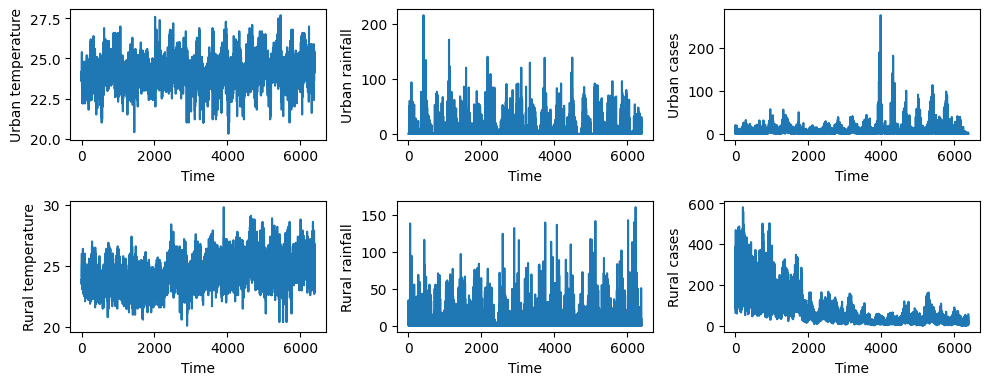

In [7]:
fig, axes  = plt.subplots(2,3, figsize = (10,4))
axes[0,0].plot(Temperature_data_urban)
axes[0,0].set_ylabel('Urban temperature')
axes[0,0].set_xlabel('Time')
axes[0,1].plot(Rainfall_data_urban)
axes[0,1].set_ylabel('Urban rainfall')
axes[0,1].set_xlabel('Time')
axes[0,2].plot(Incidence_data_urban)
axes[0,2].set_ylabel('Urban cases')
axes[0,2].set_xlabel('Time')

axes[1,0].plot(Temperature_data_rural)
axes[1,0].set_ylabel('Rural temperature')
axes[1,0].set_xlabel('Time')
axes[1,1].plot(Rainfall_data_rural)
axes[1,1].set_ylabel('Rural rainfall')
axes[1,1].set_xlabel('Time')
axes[1,2].plot(Incidence_data_rural)
axes[1,2].set_ylabel('Rural cases')
axes[1,2].set_xlabel('Time')
plt.tight_layout()
plt.show()

In [9]:
# Data for climate control
pME = 0.90
pML = 0.25
pMP = 0.75
Tmin = 14.5
tauH = 10
tauP = 1
tauE = 1
DD = 105
alpham = 0.0554
betam = -0.06737
A = -4.4
B = 1.31
C = -0.03
T1 = 19.9
D1 = 36.5
deltal = 0.2
Pa = 100
Pe = 100

#Data for resistance model
m_U = 2435/625
m_R = 2435/625
sigmav = 0.33
rv = 1.0/60.0
gammav = 1.0/9.0
phi = 0.95 #CQ+PQ
kappa = 30.0 #CQ+PQ
epsv = 2.1 #CQ+PQ
eps = 2.0
n = 1
ni = 1e-12 #CQ+PQ
alpha = 0.0 #Custo da resist?ncia
deltam = 0.033
um = 0.033
u = 0.003
ca = 0.12
cs = 0.4
psi = 1.0/60.0
rhosr = 0.5
rhors = 0.5
phit = 0.21
phiu = 0.4
uvL = 1.0/425.0

b_U=0.005095394
eta_U=0.01
RLE_U=53.19243

b_R=0.005595394#0.005595394
eta_R=0.05#0.05#0.007
RLE_R=33.0#43.19243

#awarness parameters
omega = 0.01
ini_awa_U = 0.1; ini_awa_R= 0.05; # initial awarness level (proportion of susceptible aware and using bednets)
xi = 0.1 # effect of level of infection in changing awarness
lamda = 1/120 # time of effect of awarnesslamda = 1/120 # time of effect of awarness
on_off = 0 # if zero- no awarness effect

# mobility_paramters
U_to_R1 = 0;      # rate of mobility from urban to rural
U_to_R2 = 0;      # Urban residents visiting rural return rate 
R_to_U1 = 0;      # rate of mobility from rural to urban
R_to_U2 = 0;      # rural residents visiting urban return rate 


In [10]:

def malaria_model(df_sim, Temperature_data_urban, Rainfall_data_urban, Temperature_data_rural, Rainfall_data_rural): # Macapa - Urban, Manaus- Rural
    urban_mosquito_biting = [0]*len(Temperature_data_urban)
    rural_mosquito_biting = [0]*len(Rainfall_data_urban)
    urban_mosquito_birth = [0]*len(Temperature_data_rural)
    rural_mosquito_birth = [0]*len(Rainfall_data_rural)
    urban_fraction_infection = [0]*len(Temperature_data_urban)
    rural_fraction_infection = [0]*len(Temperature_data_urban)
    
    for i in range(1, len(df_sim['tempo'])):
        
        Tt_U = Temperature_data_urban[i-1]
        R_U = Rainfall_data_urban[i-1]

        Tt_R = Temperature_data_rural[i-1]
        R_R = Rainfall_data_rural[i-1]
        
        
        if i>22*7:
            R_U = Rainfall_data_urban[i-22*7]
            R_R = Rainfall_data_rural[i-22*7]
        
        if Temperature_data_urban[i]<1.0:
            Tt_U = Temperature_data_urban[i-1]
        if Temperature_data_rural[i]<1.0:
            Tt_R = Temperature_data_rural[i-1]
            
        if i>2*7:
            Tt_U = Temperature_data_urban[i-2*7]
            Tt_R = Temperature_data_rural[i-2*7]

        #Urban Mosquito birth rate as a function of temperature
        pE_U = (4*pME/RLE_U**2)*R_U*(RLE_U - R_U)
        pLR_U = (4*pML/RLE_U**2)*R_U*(RLE_U - R_U)
        pP_U = (4*pMP/RLE_U**2)*R_U*(RLE_U - R_U)

        #Rural Mosquito birth rate as a function of temperature
        pE_R = (4*pME/RLE_R**2)*R_R*(RLE_R - R_R)
        pLR_R = (4*pML/RLE_R**2)*R_R*(RLE_R - R_R)
        pP_R = (4*pMP/RLE_R**2)*R_R*(RLE_R - R_R)
        
        if R_U > RLE_U:
            pE_U = 0.0
            pLR_U = 0.0
            pP_U = 0.0
        if R_R > RLE_R:
            pE_R = 0.0
            pLR_R = 0.0
            pP_R = 0.0
        
        
        pLT_U = np.exp(-(alpham*Tt_U+betam))
        tauL_U = 1/(alpham*Tt_U+betam)
        a_U = 0.000203*(Tt_U**2-11.7*Tt_U)*(np.sqrt(42.3-Tt_U))
        Temppp = -0.000828*Tt_U**2 + 0.0367*Tt_U + 0.522
        um_U = -np.log(-0.000828*Tt_U**2 + 0.0367*Tt_U + 0.522)#1/(A + B*Tt + C*Tt**2)
        Pc = 1e6#Pa/Pe*R
        BE_U = (-0.153*Tt_U**2+8.61*Tt_U-97.7)/um_U
        tau_U = 1/(-0.00094*Tt_U**2+0.049*Tt_U-0.0552)
        deltam_U = BE_U*pE_U*pLR_U*pLT_U*pP_U/tau_U #BE*pE*pLR*pLT*pP/(tauE+tauL+tauP)
        
        pLT_R = np.exp(-(alpham*Tt_R+betam))
        tauL_R = 1/(alpham*Tt_R+betam)
        a_R = 0.000203*(Tt_R**2-11.7*Tt_R)*(np.sqrt(42.3-Tt_R))
        um_R = -np.log(-0.000828*Tt_R**2+0.0367*Tt_R+0.522)#1/(A + B*Tt + C*Tt**2)
        Pc = 1e6#Pa/Pe*R
        BE_R = (-0.153*Tt_R**2+8.61*Tt_R-97.7)/um_R
        tau_R = 1/(-0.00094*Tt_R**2+0.049*Tt_R-0.0552)
        deltam_R= BE_R*pE_R*pLR_R*pLT_R*pP_R/tau_R #BE*pE*pLR*pLT*pP/(tauE+tauL+tauP)manu


        urban_mosquito_biting[i] = a_U
        rural_mosquito_biting[i] = a_R
        urban_mosquito_birth[i] = deltam_U
        rural_mosquito_birth[i] = deltam_R

        #Variáveis
        Sh_UU = df_sim['Sh_UU'][i-1]
        Sh_UR = df_sim['Sh_UR'][i-1]
        Ih_UU = df_sim['Ih_UU'][i-1]
        Ih_UR = df_sim['Ih_UR'][i-1]
        L_UU = df_sim['L_UU'][i-1]
        L_UR = df_sim['L_UR'][i-1]
        P_UU = df_sim['P_UU'][i-1]
        P_UR = df_sim['P_UR'][i-1]
        Sm_U = df_sim['Sm_U'][i-1]
        Im_U = df_sim['Im_U'][i-1]
        Aw_U =  df_sim['Aw_U'][i-1]
        Nh_U = df_sim['Nh_U'][i-1]
        #Nh_UR = df_sim['Nh_UR'][i-1]
        Nm_U = df_sim['Nm_U'][i-1]
        
        

        #Variáveis
        Sh_RR = df_sim['Sh_RR'][i-1]
        Sh_RU = df_sim['Sh_RU'][i-1]
        Ih_RR = df_sim['Ih_RR'][i-1]
        Ih_RU = df_sim['Ih_RU'][i-1]
        L_RR = df_sim['L_RR'][i-1]
        L_RU = df_sim['L_RU'][i-1]
        P_RR = df_sim['P_RR'][i-1]
        P_RU = df_sim['P_RU'][i-1]
        Sm_R = df_sim['Sm_R'][i-1]
        Im_R = df_sim['Im_R'][i-1]
        Aw_R =  df_sim['Aw_R'][i-1]
        Nh_R = df_sim['Nh_R'][i-1]
        #Nh_RU = df_sim['Nh_RU'][i-1]
        Nm_R = df_sim['Nm_R'][i-1]
        


        # For mosquitoes, humans present in that location contribute to transmission
        # Human presence in each region
        Nh_U = Sh_UU  +  Ih_UU + L_UU + P_UU + Sh_RU + Ih_RU + L_RU + P_RU  # UU- people stay in Urban, RU- rural resident visiting U
        Nh_R = Sh_RR  +  Ih_RR + L_RR + P_RR + Sh_UR + Ih_UR + L_UR + P_UR  #RR - Rural residents staying in R,  UR-Urban residences visiting R 

        Nm_U = Sm_U + Im_U 
        m_U = Nm_U/Nh_U

        Nm_R = Sm_R + Im_R #+ Imvr_manu
        m_R = Nm_R/Nh_R

        # Adjust force of infection using residence time
        # For humans
        lambda_Uh =  m_U * a_U * b_U * (1 - on_off * Aw_U) * Im_U / Nm_U 
        lambda_Rh =  m_R * a_R * b_R * (1 - on_off * Aw_R) * Im_R / Nm_R
        
        urban_fraction_infection[i] = lambda_Uh
        rural_fraction_infection[i] = lambda_Rh
        
        # Infected human presence (for mosquito infection)
        Ih_U_pres = Ih_UU + Ih_RU # infection in U and visitors from R
        Ih_R_pres = Ih_RR + Ih_UR # infection in R and visitors from U
        P_U_pres = P_UU + P_RU
        P_R_pres = P_RR + P_UR
        

        # infection by Ih or Ir to mosquitoes
        lambda_Uv_Ih = (a_U * cs * sigmav + a_U * ca * (1 - sigmav)) * Ih_U_pres / Nh_U
        lambda_Rv_Ih = (a_R * cs * sigmav + a_R * ca * (1 - sigmav)) * Ih_R_pres / Nh_R
        #infection by Pu or Pr to mosquitoes
        lambda_Uv_P = a_U*cs*epsv/kappa*(1-phi)*P_U_pres/Nh_U
        lambda_Rv_P = a_R*cs*epsv/kappa*(1-phi)*P_R_pres/Nh_R
        # if solution['Nh_U'].isna().any():
        #     print("Warning: 'Nh_U' contains NaN values!")
                
        #Calculating variations for Urban
        dSh_UU  =  -lambda_Uh*Sh_UU + (1-eta_U*sigmav)*(1-phiu)*rv*Ih_UU + uvL*L_UU + (1-phit*(1-phi))/kappa*P_UU - U_to_R1*Sh_UU + U_to_R2*Sh_UR 
        dSh_UR  =  -lambda_Rh*Sh_UR + (1-eta_U*sigmav)*(1-phiu)*rv*Ih_UR + uvL*L_UR + (1-phit*(1-phi))/kappa*P_UR + U_to_R1*Sh_UU - U_to_R2*Sh_UR
        dIh_UU =  lambda_Uh*Sh_UU - (1-eta_U*sigmav)*rv*Ih_UU - eta_U*sigmav*gammav*Ih_UU +  psi*L_UU + lambda_Uh*L_UU - U_to_R1*Ih_UU + U_to_R2*Ih_UR
        dIh_UR =  lambda_Rh*Sh_UR - (1-eta_U*sigmav)*rv*Ih_UR - eta_U*sigmav*gammav*Ih_UR +  psi*L_UR + lambda_Rh*L_UR + U_to_R1*Ih_UU - U_to_R2*Ih_UR
        dCases_U = lambda_Uh*Sh_UU + psi*L_UU  + lambda_Uh*L_UU + lambda_Rh*Sh_UR + psi*L_UR  + lambda_Rh*L_UR  
        dL_UU =  (1-eta_U*sigmav)*phiu*rv*Ih_UU + phit*(1-phi)/kappa*P_UU - uvL*L_UU - psi*L_UU - lambda_Uh*L_UU - U_to_R1*L_UU + U_to_R2*L_UR
        dL_UR =  (1-eta_U*sigmav)*phiu*rv*Ih_UR + phit*(1-phi)/kappa*P_UR - uvL*L_UR - psi*L_UR - lambda_Rh*L_UR + U_to_R1*L_UU - U_to_R2*L_UR
        dP_UU =  eta_U*sigmav*gammav*Ih_UU - P_UU/kappa  - U_to_R1*P_UU + U_to_R2*P_UR
        dP_UR =  eta_U*sigmav*gammav*Ih_UR - P_UR/kappa + U_to_R1*P_UU - U_to_R2*P_UR
        dSm_U = -um_U*Sm_U + deltam_U - lambda_Uv_Ih*Sm_U - lambda_Uv_P*Sm_U 
        dIm_U = -um_U*Im_U + lambda_Uv_Ih*Sm_U + lambda_Uv_P*Sm_U
        dAw_U = omega*(ini_awa_U + xi*(Ih_UU + Ih_UR))*(1- Aw_U)- lamda*Aw_U
        #Calculating variations for Rural
        dSh_RR  =  -lambda_Rh*Sh_RR  + (1-eta_R*sigmav)*(1-phiu)*rv*Ih_RR + uvL*L_RR + (1-phit*(1-phi))/kappa*P_RR - R_to_U1*Sh_RR + R_to_U2*Sh_RU  
        dSh_RU  =  -lambda_Uh*Sh_RU  + (1-eta_R*sigmav)*(1-phiu)*rv*Ih_RU + uvL*L_RU + (1-phit*(1-phi))/kappa*P_RU + R_to_U1*Sh_RR - R_to_U2*Sh_RU  
        dIh_RR =  lambda_Rh*Sh_RR - (1-eta_R*sigmav)*rv*Ih_RR - eta_R*sigmav*gammav*Ih_RR +  psi*L_RR +  lambda_Rh*L_RR - R_to_U1*Ih_RR + R_to_U2*Ih_RU 
        dIh_RU =  lambda_Uh*Sh_RU - (1-eta_R*sigmav)*rv*Ih_RU - eta_R*sigmav*gammav*Ih_RU +  psi*L_RU +  lambda_Uh*L_RU + R_to_U1*Ih_RR - R_to_U2*Ih_RU  
        dCases_R = lambda_Rh*Sh_RR +  psi*L_RR   + lambda_Rh*L_RR #+ lambda_Uh*Sh_RU + psi*L_RU + lambda_Uh*L_RU
        dL_RR =  (1-eta_R*sigmav)*phiu*rv*Ih_RR + phit*(1-phi)/kappa*P_RR - uvL*L_RR - psi*L_RR - lambda_Rh*L_RR - R_to_U1*L_RR + R_to_U2*L_RU 
        dL_RU =  (1-eta_R*sigmav)*phiu*rv*Ih_RU + phit*(1-phi)/kappa*P_RU - uvL*L_RU - psi*L_RU - lambda_Uh*L_RU + R_to_U1*L_RR - R_to_U2*L_RU     
        dP_RR =  eta_R*sigmav*gammav*Ih_RR - P_RR/kappa - R_to_U1*P_RR + R_to_U2*P_RU 
        dP_RU =  eta_R*sigmav*gammav*Ih_RU - P_RU/kappa + R_to_U1*P_RR - R_to_U2*P_RU    
        dSm_R = - um_R*Sm_R + deltam_R - lambda_Rv_Ih*Sm_R - lambda_Rv_P*Sm_R
        dIm_R = - um_R*Im_R + lambda_Rv_Ih*Sm_R + lambda_Rv_P*Sm_R
        dAw_R = omega*(ini_awa_R + xi*(Ih_RR + Ih_RU))*(1- Aw_R)- lamda*Aw_R


        #Applying variations to Macapa
        df_sim.at[i, 'Sh_UU'] = Sh_UU + dSh_UU     # Human Susceptiable
        df_sim.at[i, 'Sh_UR'] = Sh_UR + dSh_UR 
        df_sim.at[i, 'Ih_UU'] = Ih_UU + dIh_UU     # Human infectious sensitive malaria
        df_sim.at[i, 'Ih_UR'] = Ih_UR + dIh_UR
        df_sim.at[i,'L_UU'] = L_UU+ dL_UU          # Human latent sensitive malaria
        df_sim.at[i,'L_UR'] = L_UR+ dL_UR 
        df_sim.at[i,'P_UU'] = P_UU + dP_UU         # Human post treatment sensitive
        df_sim.at[i,'P_UR'] = P_UR + dP_UR    
        df_sim.at[i,'Aw_U'] = Aw_U + dAw_U         # Proportion of Macapa Susceptible people using bednets
        df_sim.at[i,'Sm_U']   = Sm_U   + dSm_U     # Mosquitos susceptibel sensitive
        df_sim.at[i,'Im_U'] = Im_U+ dIm_U          # Mosquito infectious resistance       
        df_sim.at[i,'Cases_U'] = dCases_U       
        #Updating total populations
        df_sim.at[i,'Nm_U'] = Nm_U
        df_sim.at[i,'Nh_U'] = Nh_U
        
        #Updating parameters
        m_U = df_sim.at[i,'Nm_U']/df_sim.at[i,'Nh_U']

         #Applying variations to Manaus_manu
        df_sim.at[i, 'Sh_RR'] = Sh_RR + dSh_RR    # Human Susceptiable
        df_sim.at[i, 'Sh_RU'] = Sh_RU + dSh_RU
        df_sim.at[i, 'Ih_RR'] = Ih_RR + dIh_RR    # Human infectious sensitive malaria
        df_sim.at[i, 'Ih_RU'] = Ih_RU + dIh_RU
        df_sim.at[i,'L_RR'] = L_RR + dL_RR        # Human latent sensitive malaria
        df_sim.at[i,'L_RU'] = L_RU + dL_RU
        df_sim.at[i,'P_RR'] = P_RR + dP_RR        # Human post treatment sensitive
        df_sim.at[i,'P_RU'] = P_RU + dP_RU
        df_sim.at[i,'Aw_R'] = Aw_R + dAw_R        # Proportion of Manaus Susceptible people using bednets
        df_sim.at[i,'Sm_R']   = Sm_R + dSm_R      # Mosquitos susceptibel sensitive
        df_sim.at[i,'Im_R'] = Im_R+ dIm_R         # Mosquito infectious resistance
        
        df_sim.at[i,'Cases_R'] = dCases_R

        # df_sim.at[i, 'U_R'] = dU_R
        # df_sim.at[i, 'R_U'] = dR_U
        
        #Updating total populations
        df_sim.at[i,'Nm_R'] = Nm_R
        df_sim.at[i,'Nh_R'] = Nh_R
        
        #Updating parameters
        m_R = df_sim.at[i,'Nm_R']/df_sim.at[i,'Nh_R']
    df_sim[['urban_m_birth', 'urban_m_biting', 'rural_m_birth', 'rural_m_biting', 'urban_force_of_infection', 'rural_force_of_infection']] = np.column_stack([
        urban_mosquito_birth,
        urban_mosquito_biting,
        rural_mosquito_birth,
        rural_mosquito_biting,
        urban_fraction_infection,
        rural_fraction_infection
        ])
    return df_sim


In [11]:
# Defining the time range
initial_time = 1
final_time = len(Incidence_data_urban)  
tempo = np.arange(initial_time, final_time + 1)  

#Defining the initial condition Macapa
Nh_U= 5.03327e5
Nm_U = Nh_U*m_U
init_U = 900# 900#1500#1135


#Defining the initial condition Manaus
Nh_R = 2.2e6
Nm_R = Nh_R*m_R
init_R = 10000#1500#1135
inicial = {'tempo':1, 'Sh_UU' : 1-init_U/Nh_U, 'Sh_UR' : 0, 'Ih_UU' : init_U/Nh_U, 'Ih_UR' : 0, 'L_UU' : 0, 'L_UR' : 0, 'P_UU' : 0, 'P_UR' : 0, 'Aw_U': 0, 'Sm_U' : m_U, 
             'Im_U' : 0, 'Cases_U' : 0, 'Nm_U' : Nm_U, 'Nh_U' : 1,   'Sh_RR' : 1-init_R/Nh_R, 'Sh_RU' :0, 'Ih_RR' : init_R/Nh_R, 'Ih_RU' : 0,  'L_RR' : 0, 'L_RU' : 0,
            'P_RR' : 0, 'P_RU' : 0, 'Aw_R': 0, 'Sm_R' : m_R, 'Im_R' : 0, 'Cases_R' : 0 , 'Nm_R' : Nm_R , 'Nh_R' : 1}

#Creating the results matrix
df_sim = pd.DataFrame({"tempo": tempo})
vars = ["Sh_UU", "Sh_UR", "Ih_UU", "Ih_UR", "L_UU", "L_UR", "P_UU", "P_UR",  'Aw_U', "Sm_U", "Im_U", "Cases_U", "Nm_U",  "Nh_U", 
        "Sh_RR", "Sh_RU", "Ih_RR", "Ih_RU", "L_RR", "L_RU", "P_RR", "P_RU", 'Aw_R', "Sm_R", "Im_R",  "Cases_R" , "Nm_R", "Nh_R"]
df_sim[vars] = np.nan # Initialize with NaN values
df_sim.loc[0] = inicial # Set the first row with initial conditions

In [12]:
#Observed data weekly
Urban_incidence = Macapa_data.groupby('Sem_Ano')['n'].sum().reset_index()
Manaus_data['week_year'] = Macapa_data['Sem_Ano']
Rural_incidence = Manaus_data.groupby('week_year')['n'].sum().reset_index()

In [13]:
Rural_incidence['n'].shape

(927,)

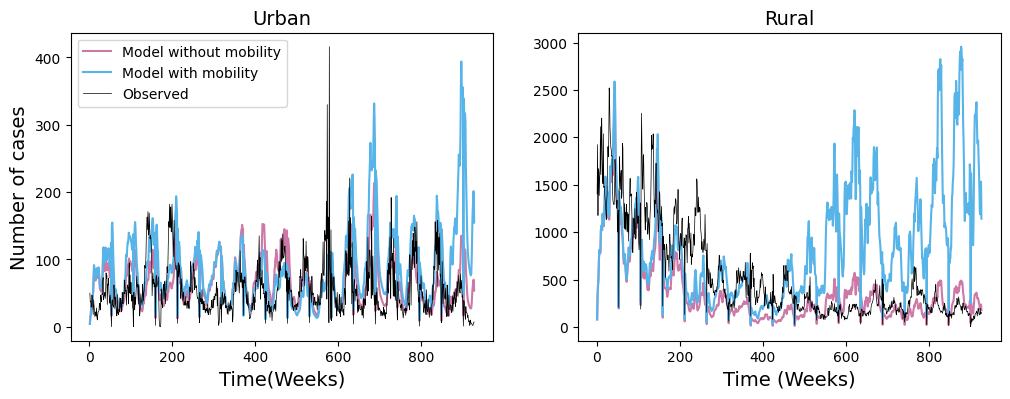

In [14]:
colors = ["#CC79A7", "#56B4E9"]
fig, axs = plt.subplots(1,2, figsize=(12,4))
awarness_values = ['Model without mobility', 'Model with mobility']

Infection_force_results = {}
on_off = 0;
for i in [0,1]:
    if i == 0:
        U_to_R1 = 0       # Time urban residents spend in rural
        U_to_R2 = 0           # Time urban residents spend in rural
        R_to_U1 = 0    
        R_to_U2 = 0
    elif i==1:
        U_to_R1 = 0# 0.005       # Time urban residents spend in rural
        U_to_R2 = 0 #1/15;           # Time urban residents spend in rural
        R_to_U1 = 0.005    
        R_to_U2 = 1/15;
      
    
    df_sim_copy = df_sim.copy(deep=True)  # use fresh copy every time
    solution =  malaria_model(df_sim_copy, Temperature_data_urban, Rainfall_data_urban, Temperature_data_rural, Rainfall_data_rural)

    
    if i == 0:
        base_cases = solution['Cases_U']
    solution['week_year'] = Macapa_data['Sem_Ano']
    
    Urban_model_cases = solution.groupby('week_year')['Cases_U'].sum().reset_index()
    Rural_model_cases = solution.groupby('week_year')['Cases_R'].sum().reset_index()
    urban_foi = solution.groupby('week_year')['urban_force_of_infection'].sum().reset_index()
    rural_foi = solution.groupby('week_year')['rural_force_of_infection'].sum().reset_index()

    Infection_force_results[i] = {
        'urban_force_of_infection': urban_foi['urban_force_of_infection'],
        'rural_force_of_infection': rural_foi['rural_force_of_infection']
        
    }
    
    Time  = range(1, len(Urban_model_cases) +1)
    Urban_model_cases['Cases_U'] = Urban_model_cases['Cases_U']*Nh_U
    Rural_model_cases['Cases_R'] = Rural_model_cases['Cases_R']*Nh_R
    
    axs[0].plot(Time, Urban_model_cases['Cases_U'], label=awarness_values[i], color=colors[i])
    axs[1].plot(Time, Rural_model_cases['Cases_R'], color=colors[i])
axs[0].plot(Time, Urban_incidence['n'], color = 'black', label = 'Observed', linewidth = 0.5)
axs[1].plot(Time, Rural_incidence['n'], color = 'black', label = 'Observed', linewidth = 0.5)
axs[0].set_xlabel('Time(Weeks)', fontsize = 14)
axs[0].set_title('Urban', fontsize = 14)
axs[1].set_xlabel('Time (Weeks)', fontsize = 14)
axs[0].set_ylabel('Number of cases', fontsize = 14 )
#axs[1].set_ylabel('Number of cases', fontsize = 14)

axs[1].set_title('Rural', fontsize = 14)
axs[0].legend()
plt.show()        

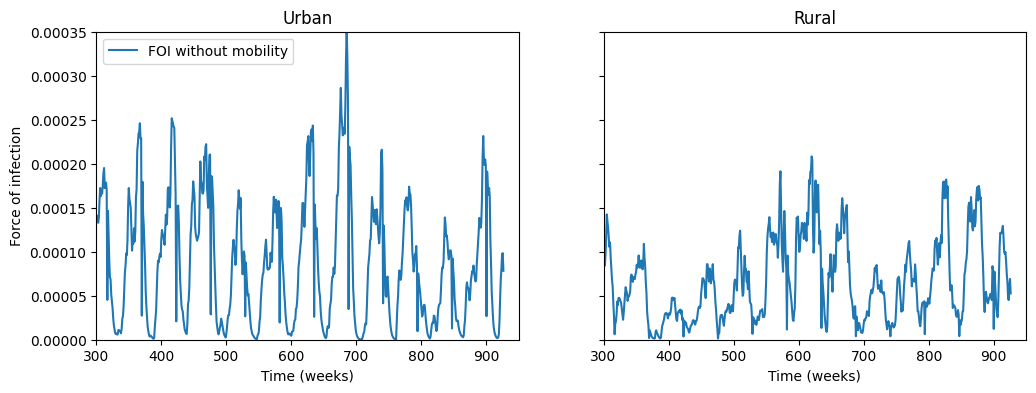

In [15]:
fig, axs = plt.subplots(1,2, figsize = (12,4), sharey=True)
labels = ['FOI without mobility', 'FOI with mobility']
for i in [0]:
    axs[0].plot(Infection_force_results[i]['urban_force_of_infection'], label = labels[i]) 
    axs[1].plot(Infection_force_results[i]['rural_force_of_infection'], label = labels[i]) 
    axs[0].set_xlim([300, 950])
    axs[1].set_xlim([300, 950])
    axs[0].set_ylim([0, 0.00035])
    #axs[1].set_ylim([0, 0.00005])
axs[0].set_title('Urban')
axs[0].set_ylabel('Force of infection')
axs[0].set_xlabel('Time (weeks)')
axs[1].set_xlabel('Time (weeks)')
axs[1].set_title('Rural')
axs[0].legend() 


In [16]:
Urban_prevalence_end_2018 = (solution['Ih_UU'].iloc[-670] + solution['P_UU'].iloc[-670])*Nh_U
Rrban_prevalence_end_2018 = (solution['Ih_RR'].iloc[-670] + solution['P_RR'].iloc[-670])*Nh_R

Urban_mosquito_2018 = (solution['Im_U'].iloc[-670])*Nm_U
Rrban_mosquito_2018 = (solution['Im_R'].iloc[-670])*Nm_R
                             
print('Urban cases initial for 2019 simulation', Urban_prevalence_end_2018)
print('Rural cases initial for 2019 simulation', Rrban_prevalence_end_2018)
print('Urban mosquto infected initial for 2019', Urban_mosquito_2018)
print('Rural mosquto infected initial for 2019', Rrban_mosquito_2018)

Urban cases initial for 2019 simulation 407.00917890440905
Rural cases initial for 2019 simulation 17980.38357294184
Urban mosquto infected initial for 2019 23529.328102293446
Rural mosquto infected initial for 2019 694325.8930574023


(0.0, 365.0)

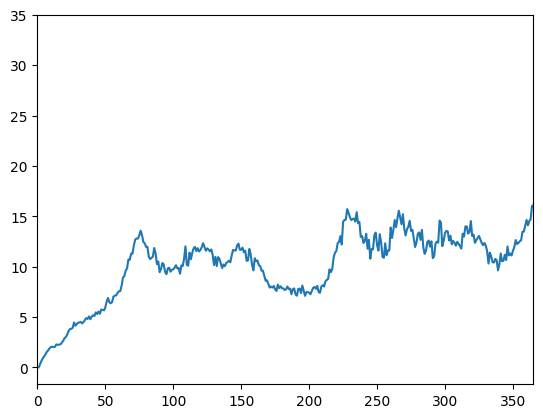

In [17]:
mm = 365 #len(solution['Cases_U'])
date = np.linspace(0,mm, mm)
plt.plot(base_cases* Nh_U)
plt.xlim([mm-365,mm])

# Effect of enviromental factors-temperature and rainfall without mobility

In [32]:
on_off  = 0
def modify_temp(temp_series, delta_T):
    return temp_series + delta_T

def modify_rain(rain_series, factor):
    return rain_series * factor

# Define temperature and rainfall scenarios
scenarios = [
    {
        "name": "Baseline",
        "delta_T_urban": 0, "factor_R_urban": 1.0,
        "delta_T_rural": 0, "factor_R_rural": 1.0
    },
    {
        "name": "Urban_only_temp_chahnge_1",
        "delta_T_urban": 1, "factor_R_urban": 1.0,
        "delta_T_rural": 0, "factor_R_rural": 1.0
    },
    {
        "name": "Urban_only_temp_chahnge_2",
        "delta_T_urban": 2, "factor_R_urban": 1.0,
        "delta_T_rural": 0, "factor_R_rural": 1.0
    },
    {
        "name": "Urban_only_rfall_chahnge_1",
        "delta_T_urban": 0, "factor_R_urban": 0.8,
        "delta_T_rural": 0, "factor_R_rural": 1.0
    },
    {
        "name": "Urban_only_rfall_chahnge_2",
        "delta_T_urban": 0, "factor_R_urban": 1.2,
        "delta_T_rural": 0, "factor_R_rural": 1.0
    },
     {
        "name": "Rural_only_temp_chahnge_1",
        "delta_T_urban": 0, "factor_R_urban": 1.0,
        "delta_T_rural": 1, "factor_R_rural": 1.0
    },
    {
        "name": "Rural_only_temp_chahnge_2",
        "delta_T_urban": 0, "factor_R_urban": 1.0,
        "delta_T_rural": 2, "factor_R_rural": 1.0
    },
    {
        "name": "Rural_only_rfall_chahnge_1",
        "delta_T_urban": 0, "factor_R_urban": 1.0,
        "delta_T_rural": 0, "factor_R_rural": 0.8
    },
    {
        "name": "Rural_only_rfall_chahnge_2",
        "delta_T_urban": 0, "factor_R_urban": 1.0,
        "delta_T_rural": 0, "factor_R_rural": 1.2
    },
]


results = {}

for scen in scenarios:
    T_u_mod = modify_temp(Temperature_data_urban, scen["delta_T_urban"])
    R_u_mod = modify_rain(Rainfall_data_urban, scen["factor_R_urban"])
    T_r_mod = modify_temp(Temperature_data_rural, scen["delta_T_rural"])
    R_r_mod = modify_rain(Rainfall_data_rural, scen["factor_R_rural"])
    
    df_sim_copy = df_sim.copy(deep=True)  # use fresh copy every time
    solution =  malaria_model(df_sim_copy, T_u_mod, R_u_mod, T_r_mod, R_r_mod)

    solution['week_year'] = Macapa_data['Sem_Ano']

    Urban_model_cases = solution.groupby('week_year')['Cases_U'].sum().reset_index()
    Rural_model_cases = solution.groupby('week_year')['Cases_R'].sum().reset_index()
    urban_mosquito_birth = solution.groupby('week_year')['urban_m_birth'].mean().reset_index()
    urban_mosquito_death = solution.groupby('week_year')['urban_m_death'].mean().reset_index()
    rural_mosquito_birth = solution.groupby('week_year')['rural_m_birth'].mean().reset_index()
    rural_mosquito_death = solution.groupby('week_year')['rural_m_death'].mean().reset_index()
     
    Cum_Urban_model_cases  = (Urban_model_cases['Cases_U']*Nh_U).cumsum()
    Cum_Rural_model_cases  = (Rural_model_cases['Cases_R']*Nh_R).cumsum()
    
    
    results[scen['name']] = {
        "urban_cases": Cum_Urban_model_cases,
        "rural_cases": Cum_Rural_model_cases,
        "urban_mosquito_birth": urban_mosquito_birth['urban_m_birth'], 
        "urban_mosquito_death": urban_mosquito_death['urban_m_death'],
        "rural_mosquito_birth": rural_mosquito_birth['rural_m_birth'],
        "rural_mosquito_death": rural_mosquito_death['rural_m_death']
        
        }

results_df = pd.DataFrame(results)

KeyError: 'Column not found: urban_m_death'

In [ ]:
mob_colors = ['black','green', 'yellow',  'red', 'purple']
Time  = range(1, len(Cum_Urban_model_cases) +1)
urban_enviromental_scenarios = ["Baseline", "Urban_only_temp_chahnge_1", "Urban_only_temp_chahnge_2", "Urban_only_rfall_chahnge_1", "Urban_only_rfall_chahnge_2"]
rural_enviromental_scenarios = ["Baseline", "Rural_only_temp_chahnge_1", "Rural_only_temp_chahnge_2", "Rural_only_rfall_chahnge_1", "Rural_only_rfall_chahnge_2"]
enviromental_labels = ['observed temp and rainfall', r'only Temp increase by $1^0$c', r'only Temp increase by $2^0$c', 'only rainfall decrease by 20%', 'only rainfall increase by 20%']
fig, axs = plt.subplots(3,2, figsize=(12,8))


for i, urban_scenario in enumerate(urban_enviromental_scenarios):
    axs[2,0].plot(Time, results[urban_scenario]["urban_cases"], label = enviromental_labels[i], color = mob_colors[i])
    axs[0,0].plot(Time,  results[urban_scenario]["urban_mosquito_birth"])
    axs[1,0].plot(Time,  results[urban_scenario]["urban_mosquito_death"])
for i, rural_scenario in enumerate(rural_enviromental_scenarios):
    axs[2,1].plot(Time, results[rural_scenario]["rural_cases"],  color = mob_colors[i])
    axs[0,1].plot(Time,  results[rural_scenario]["rural_mosquito_birth"])
    axs[1,1].plot(Time,  results[rural_scenario]["rural_mosquito_death"])
axs[2,0].legend()    
axs[2,0].set_xlabel('Time(weeks)')
axs[2,1].set_xlabel('Time(Weeks)')
axs[2,0].set_ylabel('Urban cumulative cases')
axs[2,1].set_ylabel('Rural cumulative cases')
axs[0,0].set_ylabel('Urban mosquito birth rate')
axs[1,0].set_ylabel('Urban mosquito death rate')
axs[0,1].set_ylabel('Rural mosquito birth rate')
axs[1,1].set_ylabel('Rural mosquito death rate')
# axs[0].set_title('Effect of Temperature and Rainfall change \n in urban region')
# axs[1].set_title('Effect of Temperature and Rainfall change \n in rural region')
plt.tight_layout()
plt.show()

# Effect of enviromental factors-temperature and rainfall with mobility

In [20]:
# #Baseline mobility parameter values
# U_to_R1 =  0.00017       # Time urban residents spend in rural
# U_to_R2 = 1/30;           # Time urban residents spend in rural
# R_to_U1 = 0.00206    
# R_to_U2 = 1/7;
# results2 = {}
# for scen in scenarios:
#     T_u_mod = modify_temp(Temperature_data_urban, scen["delta_T_urban"])
#     R_u_mod = modify_rain(Rainfall_data_urban, scen["factor_R_urban"])
#     T_r_mod = modify_temp(Temperature_data_rural, scen["delta_T_rural"])
#     R_r_mod = modify_rain(Rainfall_data_rural, scen["factor_R_rural"])
    
#     df_sim_copy = df_sim.copy(deep=True)  # use fresh copy every time
#     solution =  malaria_model(df_sim_copy, T_u_mod, R_u_mod, T_r_mod, R_r_mod)

#     solution['week_year'] = Macapa_data['Sem_Ano']

#     Urban_model_cases = solution.groupby('week_year')['Cases_U'].sum().reset_index()
#     Rural_model_cases = solution.groupby('week_year')['Cases_R'].sum().reset_index()
#     urban_mosquito_birth = solution.groupby('week_year')['urban_m_birth'].mean().reset_index()
#     urban_mosquito_death = solution.groupby('week_year')['urban_m_death'].mean().reset_index()
#     rural_mosquito_birth = solution.groupby('week_year')['rural_m_birth'].mean().reset_index()
#     rural_mosquito_death = solution.groupby('week_year')['rural_m_death'].mean().reset_index()
     
#     Cum_Urban_model_cases  = (Urban_model_cases['Cases_U']*Nh_U).cumsum()
#     Cum_Rural_model_cases  = (Rural_model_cases['Cases_R']*Nh_R).cumsum()
    
    
#     results2[scen['name']] = {
#         "urban_cases": Cum_Urban_model_cases,
#         "rural_cases": Cum_Rural_model_cases,
#         "urban_mosquito_birth": urban_mosquito_birth['urban_m_birth'], 
#         "urban_mosquito_death": urban_mosquito_death['urban_m_death'],
#         "rural_mosquito_birth": rural_mosquito_birth['rural_m_birth'],
#         "rural_mosquito_death": rural_mosquito_death['rural_m_death']
        
#         }

# results_df = pd.DataFrame(results2)

In [21]:
# fig, axs = plt.subplots(3,2, figsize=(12,8))


# for i, urban_scenario in enumerate(urban_enviromental_scenarios):
#     axs[2,0].plot(Time, results_df[urban_scenario]["urban_cases"], label = enviromental_labels[i], color = mob_colors[i])
#     axs[0,0].plot(Time,  results_df[urban_scenario]["urban_mosquito_birth"])
#     axs[1,0].plot(Time,  results_df[urban_scenario]["urban_mosquito_death"])
# for i, rural_scenario in enumerate(rural_enviromental_scenarios):
#     axs[2,1].plot(Time, results_df[rural_scenario]["rural_cases"],  color = mob_colors[i])
#     axs[0,1].plot(Time,  results_df[rural_scenario]["rural_mosquito_birth"])
#     axs[1,1].plot(Time,  results_df[rural_scenario]["rural_mosquito_death"])
# axs[2,0].legend()    
# axs[2,0].set_xlabel('Time(weeks)')
# axs[2,1].set_xlabel('Time(Weeks)')
# axs[2,0].set_ylabel('Urban cumulative cases')
# axs[2,1].set_ylabel('Rural cumulative cases')
# axs[0,0].set_ylabel('Urban mosquito birth rate')
# axs[1,0].set_ylabel('Urban mosquito death rate')
# axs[0,1].set_ylabel('Rural mosquito birth rate')
# axs[1,1].set_ylabel('Rural mosquito death rate')
# # axs[0].set_title('Effect of Temperature and Rainfall change \n in urban region')
# # axs[1].set_title('Effect of Temperature and Rainfall change \n in rural region')
# plt.tight_layout()
# plt.show()

# Effect of mobility

In [22]:
# rate_rural_to_urban = 0.00017 / 1826.25 # Daily fraction of people migrating over 5 years
# rate_urban_to_rural = 0.00206 / 1826.25 

# on_off = 0
# U_to_R1 =  0.00017       # Time urban residents spend in rural
# U_to_R2 = 1/30;           # Time urban residents spend in rural
# R_to_U1 = 0.00206    
# R_to_U2 = 1/7;


# mobility_scenarios = ['No mobility', 'mobility Only from rural to urban', 'mobility Only from urban to rural', 'mobility from both']
# time_U_R_values = [0*U_to_R1, 0*U_to_R1 , U_to_R1, U_to_R1]
# time_R_U_values = [0*R_to_U1, R_to_U1, 0*R_to_U1,  R_to_U1]
# colors = ["blue", "black", "purple", 'green']
# fig, axs = plt.subplots(1,2, figsize=(12,4))
# mob_colors = ['yellow', 'yellow',  'red']
# for i, (U_to_R1, R_to_U1) in enumerate(zip(time_U_R_values, time_R_U_values)):
    
#     df_sim_copy = df_sim.copy(deep=True)  # use fresh copy every time
#     solution2 =  malaria_model(df_sim_copy, Temperature_data_urban, Rainfall_data_urban, Temperature_data_rural, Rainfall_data_rural)
    
#     solution2['week_year'] = Macapa_data['Sem_Ano']
    
#     Urban_model_cases = solution2.groupby('week_year')['Cases_U'].sum().reset_index()
#     Rural_model_cases = solution2.groupby('week_year')['Cases_R'].sum().reset_index()
#     # Mobility_U_R = saida_TR.groupby('week_year')['U_R'].sum().reset_index()
#     # Mobility_R_U = saida_TR.groupby('week_year')['R_U'].sum().reset_index()
     
#     Cum_Urban_model_cases  = (Urban_model_cases['Cases_U']*Nh_U).cumsum()
#     Cum_Rural_model_cases  = (Rural_model_cases['Cases_R']*Nh_R).cumsum()

#     # Total_mobility_U_R = (Mobility_U_R['U_R']*Nh_U).cumsum()
#     # Total_mobility_R_U = (Mobility_R_U['R_U']*Nh_R).cumsum()

#     Time  = range(1, len(Urban_model_cases) +1)

#     # if i == 1:
#     #     axs[0,0].plot(Time, Total_mobility_R_U,  color = mob_colors[i])
#     # if i == 2:
#     #     axs[0,1].plot(Time, Total_mobility_U_R, color = mob_colors[i])
    
#     axs[0].plot(Time, Cum_Urban_model_cases, label= mobility_scenarios[i], color=colors[i])
#     axs[1].plot(Time, Cum_Rural_model_cases, color=colors[i])
    

# axs[0].set_xlabel('Time(weeks)')
# #axs[1,1].set_xlabel('Time(Weeks)')
# # axs[0,0].set_ylabel('Mobility from Urban to Rural')
# # axs[0,1].set_ylabel('Mobility from Rural to Urban')

# axs[0].set_ylabel('Urban cumulative cases')
# axs[1].set_ylabel('Rural cumulative cases')
# axs[0].legend()
#plt.show()        
                  
    
    

# The code in the following cell takes about 30 minutes to run - It gives the result in the contour plot. 
# I saved (using pickle- helpd to preserve the structure of the output dataframe) the result into a file and use it for future use- to prevent long time waiting each time runing the code 

In [23]:
# Reciprocal of time spent in rural and urban regions
# U_to_R2_values = [1/7, 1/15];  # Time urban residents spend in rural         

# R_to_U2_values = [1/7, 1/15];  # Time urban residents spend in rural
# length_of_visit = ['7 days', '15 days']
# nn = 10;
# U_to_R1_values = np.linspace(0,0.01,nn+1)
# R_to_U1_values = np.linspace(0,0.01, nn+1)


# Cummulative_results = {}


# for j, (U_to_R2, R_to_U2) in enumerate(zip(U_to_R2_values, R_to_U2_values)):
#     final_urban_cumulative_incidence = [[] for i in range(0,nn+1)];
#     final_rural_cumulative_incidence = [[] for i in range(0,nn+1)];
#     i = 0
#     for U_to_R1 in U_to_R1_values:
#         for R_to_U1 in  R_to_U1_values:
            
#             df_sim_copy = df_sim.copy(deep=True)  # use fresh copy every time
            
#             solution =  malaria_model(df_sim_copy, Temperature_data_urban, Rainfall_data_urban, Temperature_data_rural, Rainfall_data_rural)
        
                      
             
#             Cum_Urban_model_cases  = (solution['Cases_U']*Nh_U).sum()
#             Cum_Rural_model_cases  = (solution['Cases_R']*Nh_R).sum()

#             final_urban_cumulative_incidence[i].append(Cum_Urban_model_cases)
#             final_rural_cumulative_incidence[i].append(Cum_Rural_model_cases)

#         i = i+1
        
#     label = length_of_visit[j]
    
#     Cummulative_results[label] = {
#         'urban_cumulative': final_urban_cumulative_incidence,
#         'rural_cumulative': final_rural_cumulative_incidence
#     }


In [24]:
# levels_ci = nn+1 
# fig, axs = plt.subplots(2,2,figsize=(12,8))
# #title_lable = ['(a) \n cumulative cases ', '(b) \n cumulati ', '(c) \n Total cost ']

# for j, (U_to_R2, R_to_U2) in enumerate(zip(U_to_R2_values, R_to_U2_values)):
#     label = length_of_visit[j]
#     urban_CI = np.array(Cummulative_results[label]['urban_cumulative'])
#     rural_CI = np.array(Cummulative_results[label]['rural_cumulative'])
   
#     img0 = axs[0,j].contourf(U_to_R1_values,  R_to_U1_values, urban_CI.T, levels = levels_ci, cmap = 'rainbow') 
#     cbar = plt.colorbar(img0)
#     #cbar.set_label('Cumulative incidence', rotation=-270, labelpad=10)
#     img1 = axs[1,j].contourf(U_to_R1_values,  R_to_U1_values, rural_CI.T, levels = levels_ci, cmap = 'rainbow') 
#     cbar = plt.colorbar(img1)
#     #cbar.set_label('Cumulative incidence', rotation=-270, labelpad=10)
#     axs[0,j].set_title(length_of_visit[j])
#     axs[0,j].set_xticks([])
#     axs[j,1].set_yticks([])
    
#     axs[1,j].set_xlabel('Mobility rate from urban to rural')
#     axs[j,0].set_ylabel('Mobility rate from rural to urban')



# plt.tight_layout()
# #plt.suptitle('Cumulative incidence with varying information coverage and priortiation by immune individuals',y =1.07, fontsize=16)
# #plt.savefig('Contour_effect_reactivity.pdf', bbox_inches='tight', pad_inches=0.1, dpi =600)
# plt.show()

In [25]:
#Save with pickle, pickle preserves the structure of the result saved (cumulative_results)
# with open("cumulative_results.pkl", "wb") as f:
#     pickle.dump(Cummulative_results, f)

In [26]:
## To import  
# with open("cumulative_results.pkl", "rb") as f:
#     Cummulative_results = pickle.load(f)

In [27]:
# U_to_R2_values = [1/7, 1/15];  # Time urban residents spend in rural         

# R_to_U2_values = [1/7, 1/15];  # Time urban residents spend in rural
# length_of_visit = ['7 days', '15 days']
# nn = 10;
# U_to_R1_values = np.linspace(0,0.01,nn+1)
# R_to_U1_values = np.linspace(0,0.01, nn+1)
# levels_ci = nn+1 
# fig, axs = plt.subplots(2,2,figsize=(12,8))
# #title_lable = ['(a) \n cumulative cases ', '(b) \n cumulati ', '(c) \n Total cost ']

# for j, (U_to_R2, R_to_U2) in enumerate(zip(U_to_R2_values, R_to_U2_values)):
#     label = length_of_visit[j]
#     urban_CI = np.array(Cummulative_results[label]['urban_cumulative'])
#     rural_CI = np.array(Cummulative_results[label]['rural_cumulative'])
   
#     img0 = axs[0,j].contourf(U_to_R1_values,  R_to_U1_values, urban_CI.T, levels = levels_ci, cmap = 'rainbow') 
#     cbar0 = plt.colorbar(img0)
#     cbar0.set_label('Urban Cumulative incidence', rotation=-270, labelpad=10)
#     img1 = axs[1,j].contourf(U_to_R1_values,  R_to_U1_values, rural_CI.T, levels = levels_ci, cmap = 'rainbow') 
#     cbar1 = plt.colorbar(img1)
#     cbar1.set_label('Rural Cumulative incidence', rotation=-270, labelpad=10)
#     axs[0,j].set_title(length_of_visit[j])
#     axs[0,j].set_xticks([])
#     axs[j,1].set_yticks([])
    
#     axs[1,j].set_xlabel('Mobility rate from urban to rural')
#     axs[j,0].set_ylabel('Mobility rate from rural to urban')



# plt.tight_layout()
# #plt.suptitle('Cumulative incidence with varying information coverage and priortiation by immune individuals',y =1.07, fontsize=16)
# #plt.savefig('Contour_effect_reactivity.pdf', bbox_inches='tight', pad_inches=0.1, dpi =600)
# plt.show()

In [28]:
# U_to_R1 =  0.00017        # urban to rural commuting rate
# U_to_R2 = 1/30;           # Time urban residents spend in rural
# R_to_U1 = 0.00206         # rural to urban commuting rate
# R_to_U2 = 1/7;            # Time ruraln residents spend in urban

In [29]:
# Iu_0_conditions = [0,  init_U/Nh_U, init_U/Nh_U]
# Ir_0_conditions = [init_R/Nh_R, 0, init_R/Nh_R]
# U_to_R1_values = [0.00017, 0.00017, 0.00206]
# R_to_U1_values = [0.00017, 0.00206, 0.00017]
# fig, axs = plt.subplots(1,2, figsize=(12,4))
# figure_labels = ['Only infection in rural region', 'Only infection in Urban region', 'Infection in both region with Uniform mobility', 'Infection in both region with mobility U to R < R to U (Base case)', 'Infection in both region with mobility U to R > R to U' ]
# Colors = ['red', 'blue',  'gray', 'black', 'yellow']
# for j, (initi_Ih_U, niti_Ih_R) in enumerate(zip(Iu_0_conditions, Ir_0_conditions)):
#     inicial_scenario = {'tempo':1, 'Sh_UU' : 1-init_U/Nh_U, 'Sh_UR' : 0, 'Ih_UU' : initi_Ih_U, 'Ih_UR' : 0, 'L_UU' : 0, 'L_UR' : 0, 'P_UU' : 0, 'P_UR' : 0, 'Aw_U': 0, 'Sm_U' : m_U, 
#              'Im_U' : 0, 'Cases_U' : 0, 'Nm_U' : Nm_U, 'Nh_U' : 1,   'Sh_RR' : 1-init_R/Nh_R, 'Sh_RU' :0, 'Ih_RR' : niti_Ih_R, 'Ih_RU' : 0,  'L_RR' : 0, 'L_RU' : 0,
#             'P_RR' : 0, 'P_RU' : 0, 'Aw_R': 0, 'Sm_R' : m_R, 'Im_R' : 0, 'Cases_R' : 0 , 'Nm_R' : Nm_R , 'Nh_R' : 1}
    
#     df_sim_copy = df_sim.copy(deep=True)  # use fresh copy every time
#     df_sim_copy.loc[0] = inicial_scenario# Set the first row with initial conditions
#     if j != 2:
#         solution1 =  malaria_model(df_sim_copy, Temperature_data_urban, Rainfall_data_urban, Temperature_data_rural, Rainfall_data_rural) 
        
#     elif j == 2:
#         for i, (U_to_R1, R_to_U1) in enumerate(zip(U_to_R1_values, R_to_U1_values)):
#             solution1 =  malaria_model(df_sim_copy, Temperature_data_urban, Rainfall_data_urban, Temperature_data_rural, Rainfall_data_rural)
#             solution1['week_year'] = Macapa_data['Sem_Ano']
    
#             Urban_model_cases = solution1.groupby('week_year')['Cases_U'].sum().reset_index()
#             Rural_model_cases = solution1.groupby('week_year')['Cases_R'].sum().reset_index()
            
#             Time  = range(1, len(Urban_model_cases) +1)
#             Urban_model_cases['Cases_U'] = (Urban_model_cases['Cases_U']*Nh_U).cumsum()
#             Rural_model_cases['Cases_R'] = (Rural_model_cases['Cases_R']*Nh_R).cumsum()
            
#             axs[0].plot(Time, Urban_model_cases['Cases_U'], label=figure_labels[j +i], color=Colors [j+i])
#             axs[1].plot(Time, Rural_model_cases['Cases_R'], color=Colors[j+i])
    
    
#     solution1['week_year'] = Macapa_data['Sem_Ano']
    
#     Urban_model_cases = solution1.groupby('week_year')['Cases_U'].sum().reset_index()
#     Rural_model_cases = solution1.groupby('week_year')['Cases_R'].sum().reset_index()
    
#     Time  = range(1, len(Urban_model_cases) +1)
#     Urban_model_cases['Cases_U'] = (Urban_model_cases['Cases_U']*Nh_U).cumsum()
#     Rural_model_cases['Cases_R'] = (Rural_model_cases['Cases_R']*Nh_R).cumsum()
    
#     axs[0].plot(Time, Urban_model_cases['Cases_U'], label=figure_labels[j], color=Colors [j])
#     axs[1].plot(Time, Rural_model_cases['Cases_R'], color=Colors[j])

# axs[0].set_xlabel('Days')
# axs[1].set_xlabel('Days')
# axs[0].set_ylabel('Urban number of cases')
# axs[1].set_ylabel('Rural number of cases')
# axs[0].legend()
# plt.show()        
    
    

In [30]:
# Climate and mobility scenario 